## Autoregressive processes

$$
x_t = \rho x_{t-1} + \epsilon_t \qquad \epsilon_t \stackrel{\text{iid}}{\sim} \mathcal{N}\left(0, \sigma^2\right)
$$

### Simulating an AR(1) process

In [49]:
import numpy as np

def simulate_ar1(x0, rho, sigma, n, rng=None):
    """
    Simulates an AR(1) process.

    Parameters
    ----------
    x0 : float
        The initial value of the process.
    rho : float
        The autoregressive parameter.
    sigma : float
        The standard deviation of the noise term.
    n : int
        The number of time periods to simulate.
    rng : Generator, optional
        Random number generator to use.

    Returns
    -------
    numpy.ndarray
        An array of length `n` containing the simulated AR(1) process.
    """

    # Create an array to store the simulated values
    x = np.zeros(n)

    # Set the initial value
    x[0] = x0

    # Create RNG instance
    if rng is None:
        rng = np.random.default_rng(seed=1233)
        
    # Draw random shocks
    eps = rng.normal(0, sigma, n-1)

    # Simulate the AR(1) process
    for i in range(n-1):
        x[i+1] = rho * x[i] + eps[i]

    return x

In [50]:

seed = 1234
rng = np.random.default_rng(seed=seed)

# Initial value
x0 = 0.0

# Autoregressive parameter
rho = 0.9

# Standard deviation of the noise term
sigma = 0.1

# Number of periods to simulate
T = 100

# Simulate the AR(1) process
simulated_data = simulate_ar1(x0, 0.9, 1.0, T, rng)

Text(0.5, 1.0, 'Simulated AR(1) Process')

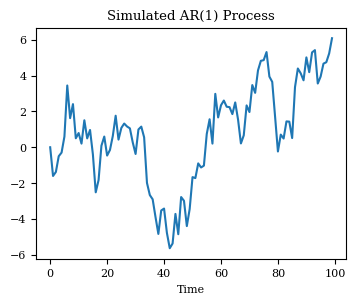

In [51]:
import matplotlib.pyplot as plt 

plt.plot(simulated_data)
plt.xlabel('Time')
plt.title('Simulated AR(1) Process')

Text(0.5, 1.0, 'Simulated AR(1) Processes')

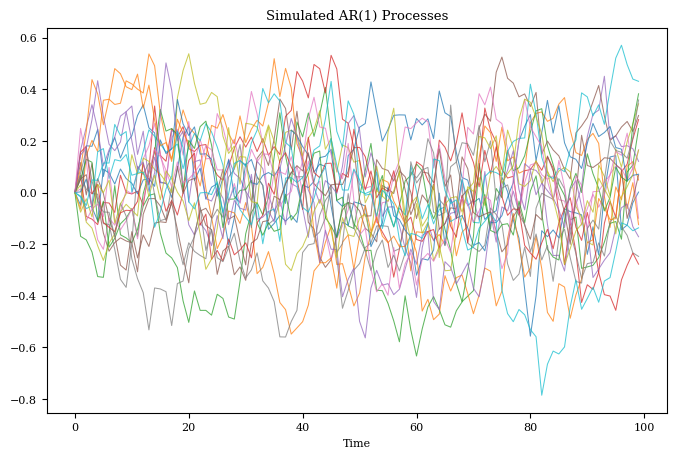

In [52]:
# Simulate 50 different sequences
N = 20

data = np.zeros((N, T))

for i in range(N):
    data[i, :] = simulate_ar1(x0, rho, sigma, T, rng)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(data.T, alpha=0.75, lw=0.75)
ax.set_xlabel('Time')
ax.set_title('Simulated AR(1) Processes')

## Wealth dynamics

$$
\begin{aligned}
a_{t+1} &= R_{t+1} \cdot s \cdot a_t + y_{t+1} \\
\log R_{t+1} &\stackrel{\text{iid}}{\sim} \mathcal{N}\left(\mu_r, \sigma_r^2 \right) \\
\log y_{t+1} &\stackrel{\text{iid}}{\sim} \mathcal{N}\left(\mu_y, \sigma_y^2 \right)
\end{aligned}
$$

### Analytical results

For a log-normally distributed variable $X$ with 
$$
\log X \stackrel{\text{iid}}{\sim} \mathcal{N}\left(\mu, \sigma^2 \right)\;,
$$
its mean (expected value) is given by
$$
\mathbb{E}X = \exp \left\{ \mu + \frac{1}{2}\sigma^2 \right\}
$$

We can use this formula to derive the mean of the stationary wealth distribution implied by the above law-of-motion (LOM).
Taking expectations on both sides of the LOM equation, we see that 
$$
\mathbb{E}[a_{t+1}] = s \mathbb{E}[ R_{t+1}] \mathbb{E}[a_t] + \mathbb{E}[y_t]
$$
 Assuming that a stationary distribution exists and the cross-sectional mean wealth is the same in every period, we must have $\mathbb{E}a_{t+1} = \mathbb{E}a_t$, and thus
$$
\mathbb{E}[a_t] = \frac{\mathbb{E}[y_t]}{1 - s \mathbb{E}[ R_{t+1}]}
 = \frac{e^{\mu_y + \frac{1}{2}\sigma_y^2}}{1 - s e^{\mu_r + \frac{1}{2}}}
$$

In [53]:
# Parameters

from dataclasses import dataclass

@dataclass
class Parameters:
    s: float = 0.9                  # Exogenous savings rate
    mu_r: float = 0.05              # Mean of log gross returns
    sigma_r: float = 0.16           # Standard deviation of log gross returns
    sigma_y: float = 0.1            # Standard deviation of log income
    mu_y: float = -0.1**2.0/2.0     # Mean of log income


In [54]:
par = Parameters()

<div class="alert alert-info">
<h3> Your turn</h3>

Simulate 100,000 income draws <i>y<sub>t</sub></i> and verify the the realizations have a mean of one.
</div>

In [55]:
# Solution

rng = np.random.default_rng(seed=1234)

N = 100_000
log_y = rng.normal(loc=par.mu_y, scale=par.sigma_y, size=N)
np.mean(np.exp(log_y))

np.float64(1.0000250158227262)

In [56]:
# Check for finite mean of stationary distribution
assert np.log(par.s) < - par.mu_r - par.sigma_r**2/2

# Mean of income 
y_mean = np.exp(par.mu_y + par.sigma_y**2/2)

# Mean return
R_mean = np.exp(par.mu_r + par.sigma_r**2/2)

# Mean of stationary distribution
a_mean = y_mean / (1 - par.s * R_mean)

print(f'Mean income:       {y_mean:.3f}')
print(f'Mean gross return: {R_mean:.3f}')
print(f'Mean wealth:       {a_mean:.3f}')

Mean income:       1.000
Mean gross return: 1.065
Mean wealth:       24.000


In [57]:
def simulate_wealth(par: Parameters, a0, T, N, rng=None):
    """
    Simulate the evolution of wealth over time.

    Parameters
    ----------
    par : Parameters
    a0 : float
        Initial wealth.
    T : int
        Number of time periods to simulate.
    N : int
        Number of individuals to simulate.
    rng : numpy.random.Generator, optional
        A random number generator instance. If None, a default RNG with a fixed seed is used.

    Returns
    -------
    a_sim : numpy.ndarray
        A (T+1, N) array where each column represents the simulated wealth path of an individual.
    """

    if rng is None:
        rng = np.random.default_rng(seed=seed)

    # Random draws of income and returns
    log_y = rng.normal(loc=par.mu_y, scale=par.sigma_y, size=(T, N))
    log_R = rng.normal(loc=par.mu_r, scale=par.sigma_r, size=(T, N))

    # Income and returns in levels
    y = np.exp(log_y)
    R = np.exp(log_R)

    a_sim = np.zeros((T+1, N))
    a_sim[0] = a0

    for t in range(T):
        # Savings out of beginning-of-period assets
        savings = par.s * a_sim[t]
        # Next-period assets
        a_sim[t+1] = R[t] * savings + y[t]

    return a_sim

In [58]:
a0 = 1.0
T = 100
N = 20

rng = np.random.default_rng(seed=1234)
a_sim = simulate_wealth(par, a0, T, N, rng)

# Mean of simulated time series
a_sim_mean = np.mean(a_sim, axis=1)

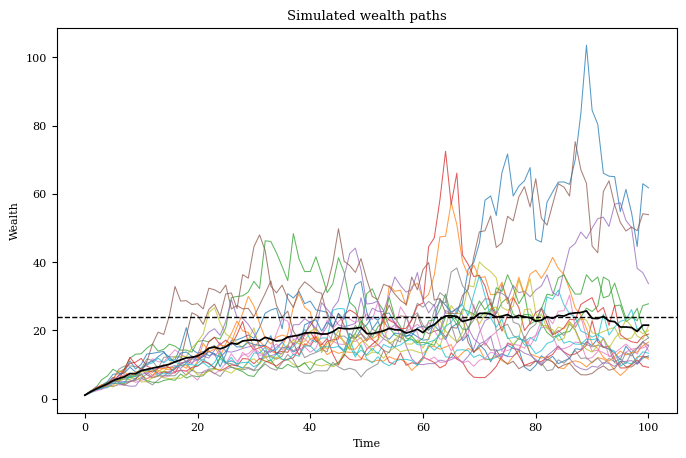

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(a_sim, alpha=0.75, lw=0.75)
ax.set_xlabel('Time')
ax.set_ylabel('Wealth')
ax.set_title('Simulated wealth paths')
ax.axhline(a_mean, color='black', ls='--', lw=1)
ax.plot(a_sim_mean, color='black', ls='-', lw=1.25)

In [60]:
# Simulate larger sample
N = 100_000
T = 1000

rng = np.random.default_rng(seed=1234)

a_sim = simulate_wealth(par, a0, T, N, rng)

# Mean of simulated time series
a_sim_mean = np.mean(a_sim, axis=1)
a_sim_var = np.var(a_sim, axis=1)

Text(0.5, 0, 'Time')

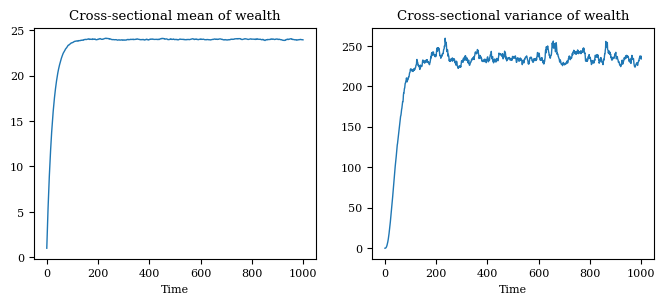

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

ax1.plot(a_sim_mean, lw=1)
ax1.set_xlabel('Time')
ax1.set_title('Cross-sectional mean of wealth')
ax2.plot(a_sim_var, lw=1)
ax2.set_title('Cross-sectional variance of wealth')
ax2.set_xlabel('Time')

In [62]:
def compute_wealth_mean(par: Parameters):
    """
    Compute the mean of the stationary wealth distribution.

    Parameters
    ----------
    par : Parameters

    Returns
    -------
    float
        The mean of the stationary wealth distribution.
    """

    y_mean = np.exp(par.mu_y + par.sigma_y**2/2)
    a_mean = y_mean / (1 - par.s * np.exp(par.mu_r + par.sigma_r**2/2))

    return a_mean

def compute_wealth_var(par: Parameters):
    """
    Compute the variance of the stationary wealth distribution.

    Parameters
    ----------
    par : Parameters

    Returns
    -------
    float
        The variance of the stationary wealth distribution.
    """

    R_mean = np.exp(par.mu_r + par.sigma_r**2/2)
    R_var = np.exp(2*par.mu_r + par.sigma_r**2) * (np.exp(par.sigma_r**2) - 1)
    y_var = np.exp(2*par.mu_y + par.sigma_y**2) * (np.exp(par.sigma_y**2) - 1)
    # Mean of stationary distribution
    a_mean = compute_wealth_mean(par)

    numerator = par.s**2 * R_var * a_mean**2 + y_var
    denominator = 1 - par.s**2 * R_var - par.s**2 * R_mean**2

    a_var = numerator / denominator

    return a_var

Text(0.5, 0, 'Time')

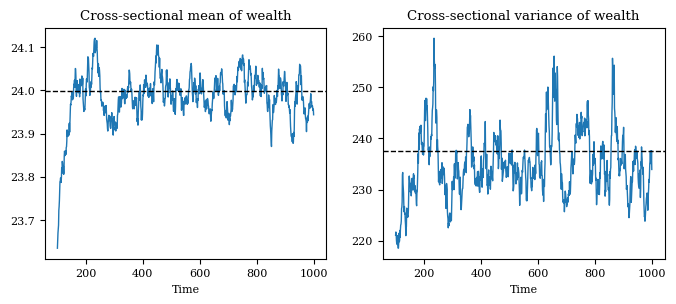

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True)

# Drop initial observations to focus on convergence
t_from = 100
xvalues = np.arange(t_from, T+1)

ax1.plot(xvalues, a_sim_mean[t_from:], lw=1)
ax1.axhline(compute_wealth_mean(par), color='black', ls='--', lw=1)
ax1.set_xlabel('Time')
ax1.set_title('Cross-sectional mean of wealth')
ax2.plot(xvalues, a_sim_var[t_from:], lw=1)
ax2.axhline(compute_wealth_var(par), color='black', ls='--', lw=1)
ax2.set_title('Cross-sectional variance of wealth')
ax2.set_xlabel('Time')

### Measures of inequality

In [64]:
def gini(x):
    """
    Compute the Gini coefficient of an array.

    Parameters
    ----------
    x : numpy.ndarray
        An array of income, wealth, etc.

    Returns
    -------
    float
        The Gini coefficient.
    """

    # Sort the array
    x_sorted = np.sort(x)

    # The number of observations
    N = len(x)

    ii = np.arange(1, N+1)

    # Compute the Gini coefficient
    G = 2*np.sum(ii * x_sorted) / (N * np.sum(x_sorted)) - (N + 1) / N

    return G

In [65]:
last_cross_section = a_sim[-1]

In [66]:
G = gini(last_cross_section)
print(f'Wealth Gini coefficient: {G:.3f}')

Wealth Gini coefficient: 0.291


### Modified savings rate

In [67]:
@dataclass
class Parameters:
    s: float = 0.9                  # Exogenous savings rate
    a_min: float = 2.0              # Minimum wealth for savings > 0
    mu_r: float = 0.05              # Mean of log gross returns
    sigma_r: float = 0.16           # Standard deviation of log gross returns
    sigma_y: float = 0.3            # Standard deviation of log income
    mu_y: float = -0.3**2.0/2.0     # Mean of log income


In [68]:
def simulate_wealth_h2m(par: Parameters, a0, T, N, rng=None):
    """
    Simulate the evolution of wealth over time.

    Parameters
    ----------
    par : Parameters
    a0 : float
        Initial wealth.
    T : int
        Number of time periods to simulate.
    N : int
        Number of individuals to simulate.
    rng : numpy.random.Generator, optional
        A random number generator instance. If None, a default RNG with a fixed seed is used.

    Returns
    -------
    a_sim : numpy.ndarray
        A (T+1, N) array where each column represents the simulated wealth path of an individual.
    """

    if rng is None:
        rng = np.random.default_rng(seed=seed)

    # Random draws of income and returns
    log_y = rng.normal(loc=par.mu_y, scale=par.sigma_y, size=(T, N))
    log_R = rng.normal(loc=par.mu_r, scale=par.sigma_r, size=(T, N))

    # Income and returns in levels
    y = np.exp(log_y)
    R = np.exp(log_R)

    a_sim = np.zeros((T+1, N))
    a_sim[0] = a0

    for t in range(T):
        # Wealth-dependent savings rate
        srate = np.where(a_sim[t] > par.a_min, par.s, 0)
        # Savings out of beginning-of-period assets
        savings = srate * a_sim[t]
        # Next-period assets
        a_sim[t+1] = R[t] * savings + y[t]

    return a_sim

In [69]:
par = Parameters()
a0 = 0.0
T = 100
N = 20

rng = np.random.default_rng(seed=1234)
a_sim = simulate_wealth_h2m(par, a0, T, N, rng)

# Mean of simulated time series
a_sim_mean = np.mean(a_sim, axis=1)

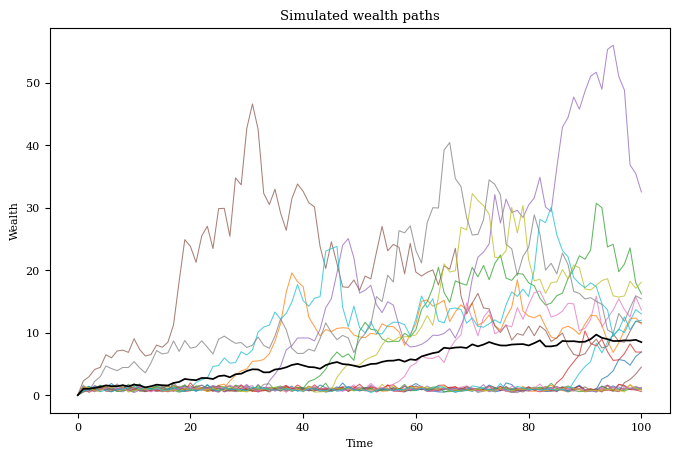

In [70]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(a_sim, alpha=0.75, lw=0.75)
ax.set_xlabel('Time')
ax.set_ylabel('Wealth')
ax.set_title('Simulated wealth paths')
ax.plot(a_sim_mean, color='black', ls='-', lw=1.25)

In [71]:
# Simulate larger sample
N = 100_000
T = 1000

rng = np.random.default_rng(seed=1234)

a_sim_h2m = simulate_wealth_h2m(par, a0, T, N, rng)

In [72]:
G = gini(a_sim_h2m[-1])
print(f'Gini coefficient with hand-to-mount households: {G:.3f}')

Gini coefficient with hand-to-mount households: 0.293
